# Data Notebook
This notebook demonstrates how to fetch historical market capitalization for a set of tickers using the helpers in `qf/core/data.py`, visualize the results, and export them to CSV.

In [1]:
# Imports and setup
import pandas as pd
from datetime import datetime
import importlib
import qf.core.data as qdata
# Explicitly reload the core data module to reflect latest changes
importlib.reload(qdata)

from qf.core.data import (
    get_historical_market_cap,
    export_market_cap_to_csv,
    get_yahoo_query_full_data,
    get_instruments_data,
    plot_time_series,
    get_yahoo_components_for_index_symbol,
    get_yahoo_query_fundametals_hist,
    get_yahoo_query_data_hist,
)


In [3]:
# Select sample tickers (S&P 500 list intersect or explicit selection)
try:
    sp = get_instruments_data()
    tickers = sp['symbol'].tolist()  # take first 10 for demo
except Exception:
    # tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META']  # fallback list
    # tickers = ['ATO.PA', '^SBF120', '^FCHI'] 
    tickers = ['^FCHI'] 


In [11]:
sp

,symbol,security_name,sector,sub_industry,date_added
0,MMM,3M,Industrials,Industrial Conglomerates,1957-03-04
1,AOS,A. O. Smith,Industrials,Building Products,2017-07-26
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,1957-03-04
3,ABBV,AbbVie,Health Care,Biotechnology,2012-12-31
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,2011-07-06
...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,2011-11-01
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,1997-10-06
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,2019-12-23
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,2001-08-07


In [4]:
# Download historical market data (daily OHLCV) for selected tickers
from qf.core.data import get_yahoo_data
import pandas as pd

# Define date range for prices
start_date_prices = '2020-01-01'
end_date_prices = pd.Timestamp.today().normalize().strftime('%Y-%m-%d')

# Single OHLCV field to retrieve
identifier = 'Close'

# Fetch prices using the helper (handles batching)
prices_df = get_yahoo_data(tickers, start_date_prices, end_date_prices, identifier=identifier)

# Sanitize index: make timezone-naive, deduplicate dates, and sort
prices_df.index = pd.to_datetime(prices_df.index, format='mixed', utc=True)
prices_df.index = prices_df.index.tz_localize(None)
prices_df = prices_df.groupby(level=0).last().sort_index()

# Preview the first rows
prices_df.head()

[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*********************100%***********************]  20 of 20 completed
[*****

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,82.398041,72.400528,69.266167,NaN,77.813850,41.268997,192.514999,334.429993,108.129189,38.799717,...,23.597670,138.416077,51.864079,53.661720,74.352036,63.830002,91.322357,137.949982,259.140015,126.972153
2020-01-03,81.075081,71.696640,68.608688,NaN,76.865273,41.221451,192.194382,331.809998,106.225700,38.723995,...,23.637814,136.363007,52.113503,53.230301,74.789673,63.000000,91.036331,137.589386,256.049988,126.991096
2020-01-06,81.314735,72.267952,69.150131,NaN,77.267960,41.383106,190.939331,333.709991,104.977684,38.421066,...,23.589645,136.093079,52.038681,53.639011,74.305473,62.570000,90.982697,136.794250,258.010010,126.016174
2020-01-07,81.563980,71.928062,68.755661,NaN,76.838394,41.040779,186.816971,333.390015,107.365990,37.958263,...,23.437094,136.738876,51.930584,53.200020,74.026123,64.589996,91.143593,136.674072,256.470001,126.442062
2020-01-08,82.369286,73.085129,69.242966,NaN,77.151611,40.631893,187.183441,337.869995,108.335678,37.537537,...,23.525410,137.596756,51.880699,52.397762,74.277542,67.599998,91.304466,138.310562,247.639999,126.167580


In [6]:
prices_df.iloc[:10]

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,82.398041,72.400528,69.266167,NaN,77.813850,41.268997,192.514999,334.429993,108.129189,38.799717,...,23.597670,138.416077,51.864079,53.661720,74.352036,63.830002,91.322357,137.949982,259.140015,126.972153
2020-01-03,81.075081,71.696640,68.608688,NaN,76.865273,41.221451,192.194382,331.809998,106.225700,38.723995,...,23.637814,136.363007,52.113503,53.230301,74.789673,63.000000,91.036331,137.589386,256.049988,126.991096
2020-01-06,81.314735,72.267952,69.150131,NaN,77.267960,41.383106,190.939331,333.709991,104.977684,38.421066,...,23.589645,136.093079,52.038681,53.639011,74.305473,62.570000,90.982697,136.794250,258.010010,126.016174
2020-01-07,81.563980,71.928062,68.755661,NaN,76.838394,41.040779,186.816971,333.390015,107.365990,37.958263,...,23.437094,136.738876,51.930584,53.200020,74.026123,64.589996,91.143593,136.674072,256.470001,126.442062
2020-01-08,82.369286,73.085129,69.242966,NaN,77.151611,40.631893,187.183441,337.869995,108.335678,37.537537,...,23.525410,137.596756,51.880699,52.397762,74.277542,67.599998,91.304466,138.310562,247.639999,126.167580
2020-01-09,83.663498,74.637520,69.776665,NaN,77.357452,41.459175,188.850662,340.450012,108.335678,37.150463,...,23.718105,137.018402,51.997105,52.798897,74.612762,67.930000,92.028481,137.395218,246.500000,127.843025
2020-01-10,83.970268,74.806213,68.887154,NaN,76.390945,41.392612,190.233994,339.809998,106.459152,36.982166,...,23.742197,137.847382,52.080250,52.329624,74.435837,67.989998,90.893318,138.680374,246.270004,128.325745
2020-01-13,83.845657,76.404427,68.469437,NaN,76.176140,41.544754,192.002014,345.630005,106.899109,37.377644,...,24.288179,141.895767,52.687183,52.829155,75.683578,68.660004,89.686638,137.783569,248.580002,129.215530
2020-01-14,84.353729,75.372719,69.143661,NaN,77.056923,41.525738,190.298111,344.630005,107.321091,37.444977,...,24.601313,144.613968,52.770321,52.375053,75.767395,68.169998,90.026299,137.154861,248.070007,129.934906


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Time Series: MMM, AOS, ABT, ABBV, ACN, ADBE, AMD, AES, AFL, A'}, xlabel='Date', ylabel='Value (normalized)'>)

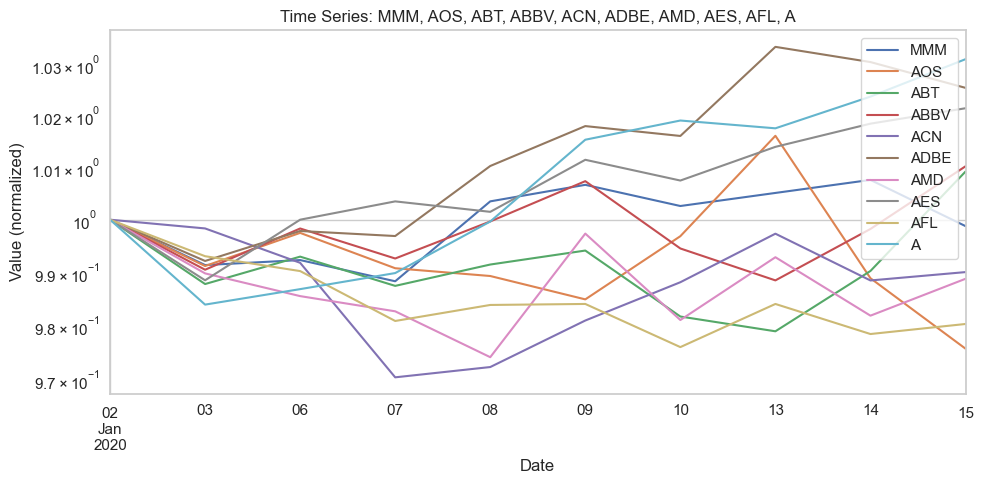

In [7]:
plot_time_series(prices_df.iloc[:10], tickers[:10], start_date=start_date_prices, end_date=end_date_prices, normalize=True, log_scale=True)

In [4]:
    # tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META']  # fallback list
# tickers = ['ATO.PA', '^SBF120', '^FCHI'] 
tickers = ['ATO.PA']

In [5]:
fundamentals_df = get_yahoo_query_full_data(tickers=tickers)

In [6]:
fundamentals_df

,symbol,current_price,return_on_equity,return_on_assets,debt_to_equity,current_ratio,quick_ratio,revenue,ebitda,free_cash_flow,...,fifty_two_week_change,volume,average_volume,market_cap,beta,dividend_yield,dividend_rate,ex_dividend_date,long_name,summary
0,ATO.PA,46.58,None,-0.01271,None,1.473,1.191,8632999936,140000000,447750016,...,None,101455,106723,902637888,1.701,None,None,2021-05-14 01:00:00,Atos SE,Atos SE provides digital transformation soluti...


In [ ]:
fundamentals_df = get_yahoo_query_full_data(tickers=tickers)

In [ ]:
from yahooquery import Ticker


tq = Ticker(symbols=tickers[0], session=None)

statements = ['income_statement', 'balance_sheet', 'cash_flow']

print(tq.income_statement())

         asOfDate periodType currencyCode  BasicAverageShares  BasicEPS  \
symbol                                                                    
MMM    2021-12-31        12M          USD                 NaN       NaN   
MMM    2022-12-31        12M          USD         566000000.0     10.21   
MMM    2023-09-30        TTM          USD         553250000.0    -13.31   
MMM    2023-12-31        12M          USD         553900000.0    -12.63   
MMM    2023-12-31        TTM          USD         553900000.0    -12.63   
MMM    2024-03-31        TTM          USD         554475000.0    -12.73   
MMM    2024-06-30        TTM          USD         554450000.0      1.71   
MMM    2024-09-30        TTM          USD         553450000.0      7.94   
MMM    2024-12-31        12M          USD         550800000.0      7.58   
MMM    2024-12-31        TTM          USD         550800000.0      7.58   
MMM    2025-03-31        TTM          USD         548000000.0      7.96   
MMM    2025-06-30        

In [7]:
tq

yfinance.Ticker object <MMM>

In [2]:
tikers_for_hist = ['ATOS.PA']

In [7]:
# Historical fundamentals (financial statements): tidy long format
fundamentals_hist_df = get_yahoo_query_fundametals_hist(
    tickers=tikers_for_hist,
    period_type='quarter',
    output_format='long'
)



AttributeError: 'str' object has no attribute 'empty'

In [4]:
fundamentals_hist_df.head()

""


In [ ]:
fundamentals_hist_df

In [45]:
mc_tickers = ['ATO.PA']
# Fetch historical market cap using price * shares outstanding


In [46]:
# Fetch historical market cap using price * shares outstanding
start_date = '2020-01-01'
end_date = pd.Timestamp.today().normalize().strftime('%Y-%m-%d')
mc_df = get_historical_market_cap(mc_tickers, start_date, end_date)
mc_df.head()

[*********************100%***********************]  1 of 1 completed


,ATO.PA
Date,
2020-01-02,6.016702e+11
2020-01-03,5.987990e+11
2020-01-06,5.914616e+11
2020-01-07,6.141119e+11
2020-01-08,6.113394e+11


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Time Series: ATO.PA'}, xlabel='Date', ylabel='Value (normalized)'>)

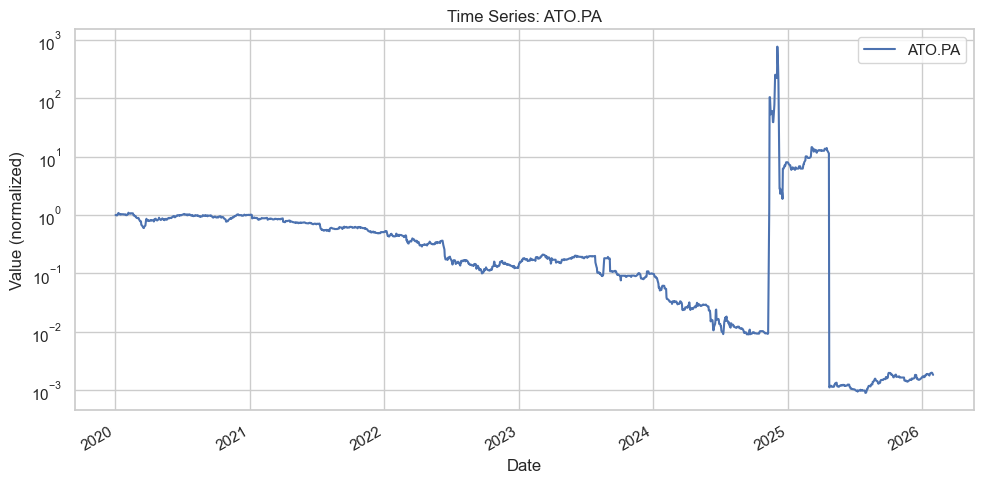

In [48]:
# Plot a few tickers (normalized for comparability)
plot_time_series(mc_df, mc_tickers, start_date=start_date, end_date=end_date, normalize=True, log_scale=True)

Atos SE (ATO.PA) is listed on Euronext Paris and is a component of the SBF 120 index. 
While historically part of the CAC 40, Atos was removed from the benchmark index in 2021 due to a drop in market capitalization. 
Key index associations and classifications:
Primary Index: SBF 120
Sector: Information Technology Services
Market: Euronext Paris (Compartment A) 
As of early 2025, the company is undergoing a restructuring process, including a reverse stock split, but remains listed on the Euronext Paris exchange. 

In [ ]:
# Export to CSV
out_path = '/Users/yevgeniy/Development/Projects/FinancialEngineering/quant-finance/data/market_cap.csv'
export_market_cap_to_csv(mc_df, out_path)
out_path

In [5]:
df = get_yahoo_components_for_index_symbol('SBF120', columns=['symbol', 'shortName'])
df.head()

/Users/yevgeniy/Development/Projects/FinancialEngineering/quant-finance/qf/core/data.py:650: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(resp.text)


,symbol
0,^SBF120


In [ ]:
symbols = ['ATOS.PA']

## given a list of symbols, use yahooquery to get historical data snapshot by given date range


In [ ]:
# Historical OHLCV via yahooquery for a date range\nfrom qf.core.data import get_yahoo_query_data_hist\n\n# Define symbols and date range\nsymbols = ['AAPL', 'MSFT']  # replace with your tickers\nstart_date = '2022-01-01'\nend_date = '2023-12-31'\n\n# Wide format: date index with suffixed columns per (ticker, field)\ndf_wide = get_yahoo_query_data_hist(\n    tickers=symbols,\n    start=start_date,\n    end=end_date,\n    fields=['open','high','low','close','adjclose','volume'],\n    output_format='wide',\n    column_order='ticker_field',\n    interval='1d'\n)\ndf_wide.head()

In [ ]:
# Tidy (long) format: Date, Ticker, Field, Value\ndf_long = get_yahoo_query_data_hist(\n    tickers=symbols,\n    start=start_date,\n    end=end_date,\n    fields=['open','high','low','close','adjclose','volume'],\n    output_format='long',\n    interval='1d'\n)\ndf_long.head()

In [17]:
symbols = ['ATO.PA']
start_date = pd.to_datetime('2026-01-01')
end_date = pd.to_datetime('2026-01-31')

In [18]:
# Optional: Direct yahooquery usage without helper
from yahooquery import Ticker

tq = Ticker(symbols, asynchronous=True)
hist_raw = tq.history(start=start_date, end=end_date, interval='1d')

df_raw = hist_raw.reset_index() if isinstance(hist_raw.index, pd.MultiIndex) else hist_raw.copy()
df_raw.head()

,symbol,date,open,high,low,close,volume,adjclose
0,ATO.PA,2026-01-02,51.000000,54.799999,51.000000,52.139999,148071,52.139999
1,ATO.PA,2026-01-05,52.959999,53.330002,49.099998,50.250000,136552,50.250000
2,ATO.PA,2026-01-06,50.250000,52.400002,49.150002,52.220001,79308,52.220001
3,ATO.PA,2026-01-07,51.849998,53.500000,51.630001,53.490002,72992,53.490002
4,ATO.PA,2026-01-08,53.049999,53.720001,51.570000,51.570000,62292,51.570000


In [19]:
import pandas as pd
from yahooquery import Ticker

symbols = ['AAPL', 'MSFT']
start_fund = '2024-01-01'
end_fund = '2024-12-31'

tq = Ticker(symbols, asynchronous=True)

def _prep_stmt(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    df = df.reset_index() if isinstance(df.index, pd.MultiIndex) else df.copy()
    # Ensure 'symbol' and 'asOfDate'
    if 'symbol' not in df.columns and df.index.name == 'symbol':
        df = df.reset_index()
    if 'asOfDate' not in df.columns:
        for c in df.columns:
            if 'date' in str(c).lower():
                df = df.rename(columns={c: 'asOfDate'})
                break
    # Keep relevant columns (numeric metrics + keys)
    meta_cols = {'symbol', 'asOfDate', 'periodType', 'currencyCode', 'reportedCurrency', 'endDate'}
    value_cols = [c for c in df.columns if c not in meta_cols and pd.api.types.is_numeric_dtype(df[c])]
    keep = ['symbol', 'asOfDate'] + value_cols
    df = df[keep].copy()
    # Normalize dates
    df['asOfDate'] = pd.to_datetime(df['asOfDate'], utc=True).dt.tz_localize(None)
    # Tag statement
    df['Statement'] = name
    return df

inc = _prep_stmt(tq.income_statement(), 'income_statement')
bal = _prep_stmt(tq.balance_sheet(), 'balance_sheet')
cf  = _prep_stmt(tq.cash_flow(), 'cash_flow')

all_df = pd.concat([inc, bal, cf], axis=0, ignore_index=True)
all_df = (all_df
          .sort_values(['asOfDate', 'symbol', 'Statement'])
          .groupby(['asOfDate', 'symbol', 'Statement'], as_index=False)
          .last())

# Long format
long_df = all_df.melt(id_vars=['symbol', 'asOfDate', 'Statement'],
                      var_name='Field', value_name='Value')
long_df = long_df.rename(columns={'symbol': 'Ticker', 'asOfDate': 'Date'})

# Filter by range
long_df['Date'] = pd.to_datetime(long_df['Date'])
long_df_range = long_df[
    (long_df['Date'] >= pd.to_datetime(start_fund)) &
    (long_df['Date'] <= pd.to_datetime(end_fund))
]

print("\nDirect yahooquery long format, filtered:")
print(long_df_range.sort_values(['Date', 'Ticker', 'Statement', 'Field']).head())


Direct yahooquery long format, filtered:
     Ticker       Date         Statement  \
2229   AAPL 2024-03-31  income_statement   
2276   AAPL 2024-03-31  income_statement   
2323   AAPL 2024-03-31  income_statement   
2370   AAPL 2024-03-31  income_statement   
6224   AAPL 2024-03-31  income_statement   

                                       Field  Value  
2229                         AccountsPayable    NaN  
2276                      AccountsReceivable    NaN  
2323                 AccumulatedDepreciation    NaN  
2370  AllowanceForDoubtfulAccountsReceivable    NaN  
6224                   AssetImpairmentCharge    NaN  


In [21]:
# Valuation multiples snapshot (EV/EBITDA, EV/Sales, PE, PB)
import pandas as pd
import numpy as np
from qf.core.data import get_yahoo_query_full_data
# Use existing symbols if defined; otherwise default
symbols = symbols if 'symbols' in globals() else ['ATO.PA']

# Fetch snapshot fundamentals/summary data (cached)
snap = get_yahoo_query_full_data(tickers=symbols)

# Normalize index to ticker symbol when present
if 'symbol' in snap.columns:
    snap = snap.set_index('symbol')

# Helper to pick the first available column from candidates
def pick(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return df[c].astype(float)
    return pd.Series(np.nan, index=df.index)

market_cap = pick(snap, ['marketCap'])
enterprise_value = pick(snap, ['enterpriseValue'])
ebitda = pick(snap, ['ebitda','EBITDA','Ebitda'])
revenue = pick(snap, ['totalRevenue','Revenue','revenue'])
trailing_pe = pick(snap, ['trailingPE','trailingPe'])
forward_pe = pick(snap, ['forwardPE'])
price_to_book = pick(snap, ['priceToBook'])
ev_to_ebitda = pick(snap, ['enterpriseValueToEbitda','evToEbitda'])
ev_to_sales = pick(snap, ['enterpriseValueToRevenue','evToSales'])

# Derive multiples if not provided
ev_to_ebitda = ev_to_ebitda.where(~ev_to_ebitda.isna(), enterprise_value / ebitda)
ev_to_sales = ev_to_sales.where(~ev_to_sales.isna(), enterprise_value / revenue)

result = pd.DataFrame({
    'MarketCap': market_cap,
    'EnterpriseValue': enterprise_value,
    'EBITDA': ebitda,
    'Revenue': revenue,
    'TrailingPE': trailing_pe,
    'ForwardPE': forward_pe,
    'PriceToBook': price_to_book,
    'EV_to_EBITDA': ev_to_ebitda,
    'EV_to_Sales': ev_to_sales,
})
result

,MarketCap,EnterpriseValue,EBITDA,Revenue,TrailingPE,ForwardPE,PriceToBook,EV_to_EBITDA,EV_to_Sales
symbol,,,,,,,,,
ATO.PA,NaN,NaN,140000000.0,8.633000e+09,NaN,NaN,NaN,NaN,NaN


In [23]:
# Optional: historical quarterly EV/EBITDA approximation (robust to missing Date column)
import pandas as pd
from qf.core.data import get_yahoo_query_fundametals_hist, get_yahoo_query_data_hist, get_yahoo_query_full_data

# Symbols and date range for prices
symbols = symbols if 'symbols' in globals() else ['AAPL','MSFT']
start_prices = '2024-01-01'
end_prices = '2024-12-31'

# Quarterly fundamentals (long)
fund_long = get_yahoo_query_fundametals_hist(tickers=symbols, period_type='quarter', output_format='long')

# Ensure a 'Date' column exists
def ensure_date_col(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=['Date','Ticker','Statement','Field','Value'])
    cols = set(df.columns)
    if 'Date' in cols:
        return df
    if 'asOfDate' in cols:
        return df.rename(columns={'asOfDate': 'Date'})
    # Try to detect any datetime-like column
    for c in df.columns:
        try:
            if pd.api.types.is_datetime64_any_dtype(df[c]):
                return df.rename(columns={c: 'Date'})
        except Exception:
            continue
    # Fallback: attempt to parse a column that looks like a date
    for c in df.columns:
        if 'date' in str(c).lower():
            return df.rename(columns={c: 'Date'})
    return df  # leave as-is if no reasonable match

# Normalize/parse dates if present
fund_long = ensure_date_col(fund_long)
if 'Date' in fund_long.columns:
    fund_long['Date'] = pd.to_datetime(fund_long['Date'], errors='coerce')

# Guard for empty after parsing
if fund_long.empty or 'Field' not in fund_long.columns or 'Ticker' not in fund_long.columns:
    {'EV_to_EBITDA_quarterly': pd.DataFrame(), 'EV_to_Sales_quarterly': pd.DataFrame()}
else:
    # Select candidate fields using case-insensitive matching
    def pick_field(df, pattern):
        return df[df['Field'].astype(str).str.lower().str.contains(pattern, na=False)].copy()
    
    # EBITDA/EBITA, Total Debt, Cash, Revenue
    ebitda_q = pick_field(fund_long, 'ebitda|ebita')
    debt_q = pick_field(fund_long, 'totaldebt|debt')
    cash_q = pick_field(fund_long, 'cashandcashequivalents|cash\b')
    revenue_q = pick_field(fund_long, 'totalrevenue|revenue')
    
    # Pivot to Date x Ticker
    def pivot_metric(df):
        if df is None or df.empty:
            return pd.DataFrame()
        return df.pivot_table(index='Date', columns='Ticker', values='Value').sort_index()
    
    EBITDA = pivot_metric(ebitda_q)
    TOTAL_DEBT = pivot_metric(debt_q)
    CASH = pivot_metric(cash_q)
    REVENUE = pivot_metric(revenue_q)
    
    # Daily close prices, then take last close per quarter
    prices_long = get_yahoo_query_data_hist(tickers=symbols, start=start_prices, end=end_prices, fields=['close'], output_format='long')
    if not prices_long.empty and {'Date','Ticker','Field','Value'}.issubset(prices_long.columns):
        prices_long['Date'] = pd.to_datetime(prices_long['Date'], errors='coerce')
        close_wide = prices_long.pivot_table(index='Date', columns='Ticker', values='Value').sort_index()
        close_q = close_wide.resample('Q').last()
    else:
        close_q = pd.DataFrame()
    
    # Shares outstanding from snapshot (approximation)
    snap = get_yahoo_query_full_data(tickers=symbols)
    if 'symbol' in snap.columns:
        snap = snap.set_index('symbol')
    shares = snap['sharesOutstanding'] if 'sharesOutstanding' in snap.columns else pd.Series(index=snap.index)
    
    # Compute quarterly market cap (approximation)
    market_cap_q = close_q.copy()
    if not market_cap_q.empty:
        for t in market_cap_q.columns:
            if t in shares.index and pd.notna(shares.loc[t]):
                market_cap_q[t] = market_cap_q[t].astype(float) * float(shares.loc[t])
            else:
                market_cap_q[t] = pd.NA
    
    # Compute EV = MarketCap + Debt - Cash (aligned to quarter)
    EV = market_cap_q.align(TOTAL_DEBT, join='left')[0] + TOTAL_DEBT.align(market_cap_q, join='left')[0] - CASH.align(market_cap_q, join='left')[0]
    
    # EV/EBITDA and EV/Sales
    EV_to_EBITDA_q = EV / EBITDA if not EBITDA.empty else pd.DataFrame()
    EV_to_Sales_q = EV / REVENUE if not REVENUE.empty else pd.DataFrame()
    
    {'EV_to_EBITDA_quarterly': EV_to_EBITDA_q.head(), 'EV_to_Sales_quarterly': EV_to_Sales_q.head()}